# UT signal aligner

In this notebook you can align the signals of ut volumes to a single point, so all the frontwalls are in the same Z position.

To do it you just have to:

- Set the path of the volume in the variable **volume_path**
- Set the alignment point in the variable **align_point**

The aligned volume will be saved in the same folder as the original volume with the same name + **_aligned** at the end

## imports

In [1]:
from pathlib import Path
from preprocess_tools import io, signal
from matplotlib import pyplot as plt
import numpy as np

## Loading data

In [2]:
volume_path = Path(r"/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/03_UT_data/Fabricacion Nacho/probetas/5MHz/Na_01_1/Na_01_1.tif")
saving_folder = Path(str(volume_path).replace('.tif','_aligned.tif'))
print(f"Loading volume from {volume_path}")
io.load_tif(volume_path)
print(f"Volume will be saved as amplitude volume to {saving_folder}")

Loading volume from /home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/03_UT_data/Fabricacion Nacho/probetas/5MHz/Na_01_1/Na_01_1.tif
Volume will be saved as amplitude volume to /home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/03_UT_data/Fabricacion Nacho/probetas/5MHz/Na_01_1/Na_01_1_aligned.tif


In [3]:
#load file
volume = io.load_tif(volume_path)

print(f"Volume loaded with shape: {volume.shape}")

Volume loaded with shape: (448, 132, 49)


/tmp/ipykernel_4188660/617933042.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


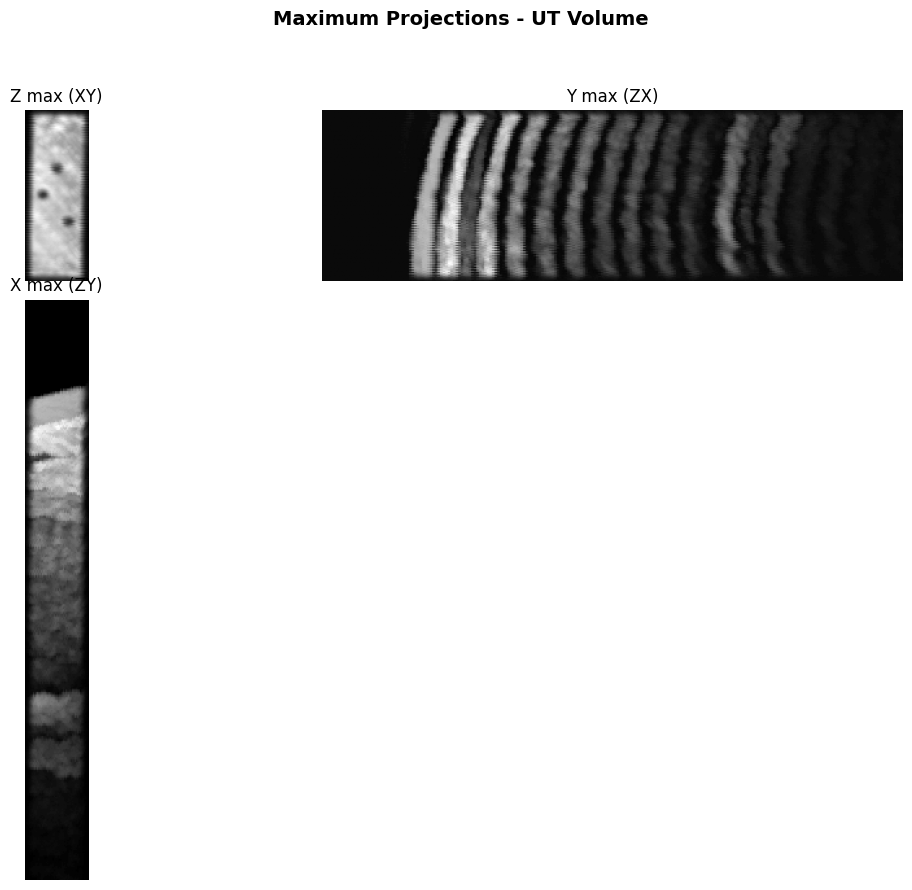

In [4]:
#Figure that shows the max projection of each axes
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[132, 448], width_ratios=[132, 448], hspace=0.05, wspace=0.05)

fig.suptitle('Maximum Projections - UT Volume', fontsize=14, fontweight='bold')

# Main projection (XY) - top left
ax0 = fig.add_subplot(gs[0, 0])
ax0.imshow(volume.max(axis=0), cmap='gray')
ax0.set_title('Z max (XY)', fontsize=12)
ax0.axis('off')

# Y max projection (shares X axis) - top right
ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(np.rot90(volume.max(axis=2)), cmap='gray')
ax2.set_title('Y max (ZX)', fontsize=12)
ax2.axis('off')

# X max projection (shares Y axis) - bottom left
ax1 = fig.add_subplot(gs[1, 0])
ax1.imshow(volume.max(axis=1), cmap='gray')
ax1.set_title('X max (ZY)', fontsize=12)
ax1.axis('off')

plt.tight_layout()
plt.show()

## Alignment

In [5]:
#align point
align_point = 50

In [6]:
aligned_volume = volume.reshape((volume.shape[0], volume.shape[1]* volume.shape[2]))
aligned_volume = aligned_volume.T.reshape((aligned_volume.shape[1],1, aligned_volume.shape[0]))

aligned_volume = signal.align_signals_optimized(aligned_volume,align_point)

aligned_volume = aligned_volume.reshape((volume.shape[1]* volume.shape[2]),volume.shape[0]).T
aligned_volume = aligned_volume.reshape(volume.shape)

Aligning signal batches: 100%|██████████| 65/65 [00:00<00:00, 1233.79it/s]


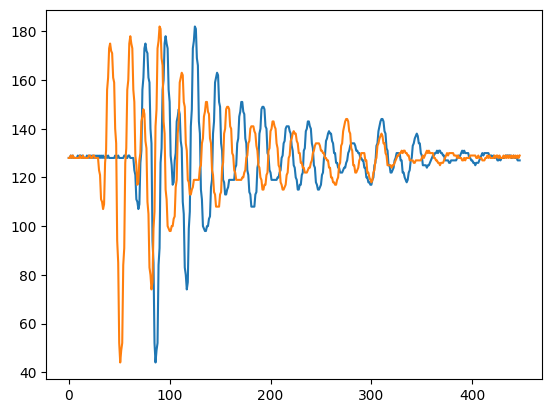

In [7]:
signal_original = volume[:,30,30]
aligned_signal = aligned_volume[:,30,30]

plt.plot(signal_original)
plt.plot(aligned_signal)

/tmp/ipykernel_4188660/3542034231.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


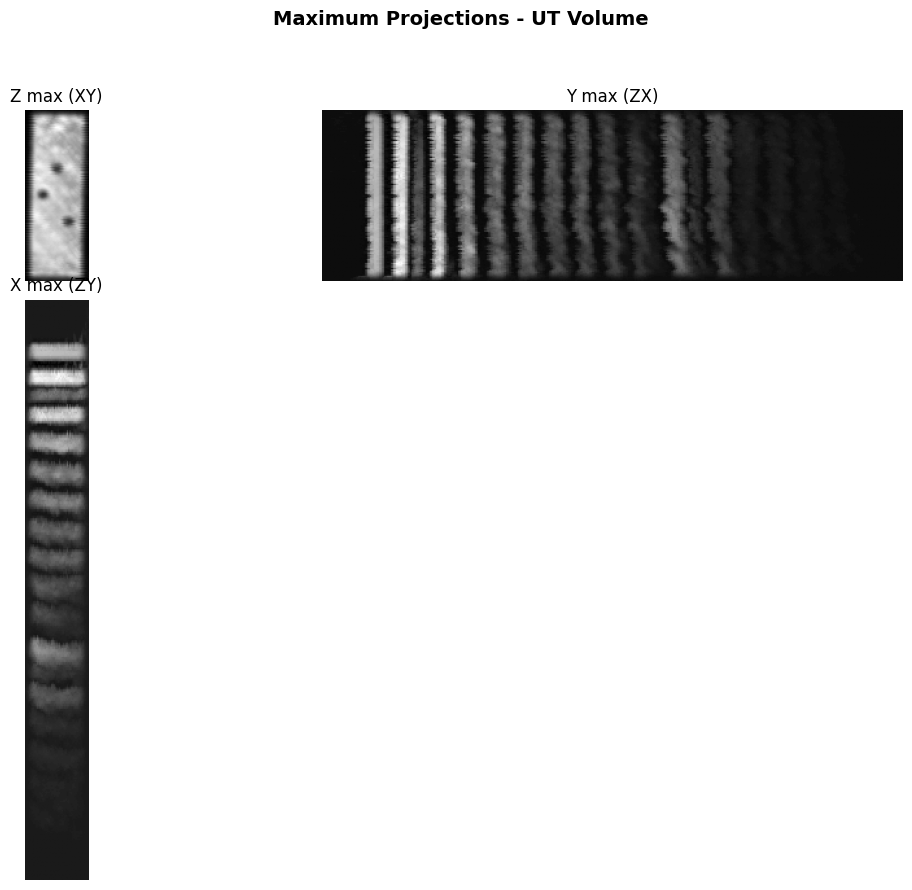

In [8]:
#Figure that shows the max projection of each axes
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[132, 448], width_ratios=[132, 448], hspace=0.05, wspace=0.05)

fig.suptitle('Maximum Projections - UT Volume', fontsize=14, fontweight='bold')

# Main projection (XY) - top left
ax0 = fig.add_subplot(gs[0, 0])
ax0.imshow(aligned_volume.max(axis=0), cmap='gray')
ax0.set_title('Z max (XY)', fontsize=12)
ax0.axis('off')

# Y max projection (shares X axis) - top right
ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(np.rot90(aligned_volume.max(axis=2)), cmap='gray')
ax2.set_title('Y max (ZX)', fontsize=12)
ax2.axis('off')

# X max projection (shares Y axis) - bottom left
ax1 = fig.add_subplot(gs[1, 0])
ax1.imshow(aligned_volume.max(axis=1), cmap='gray')
ax1.set_title('X max (ZY)', fontsize=12)
ax1.axis('off')

plt.tight_layout()
plt.show()

## Save to disk

In [9]:
#saving
io.save_tif(saving_folder, aligned_volume.astype(volume.dtype))